✔  Dados carregados com sucesso.

── Nº de empresas com inovação ──
         setor    2008    2011    2014    2017
     Alimentos 11723.0 14013.0 13846.0 14362.0
       Bebidas   889.0   926.0   967.0  1043.0
      Químicos  3064.0  3517.0  3632.0  3509.0
Máq. Agrícolas     NaN   727.0   806.0   840.0

── Dispêndios em inovação (Mil R$) ──
                                                                              setor      2008      2011      2014      2017
Atividades da indústria, do setor de eletricidade e gás e dos serviços selecionados    2008.0    2011.0    2014.0    2017.0
                                                                          Alimentos 5823511.0 7814361.0 7106516.0 6398946.0
                                                                            Bebidas  894340.0 1273885.0 2152772.0 1042798.0
                                                                           Químicos 4279988.0 4583634.0 4748945.0 5879315.0
                                      

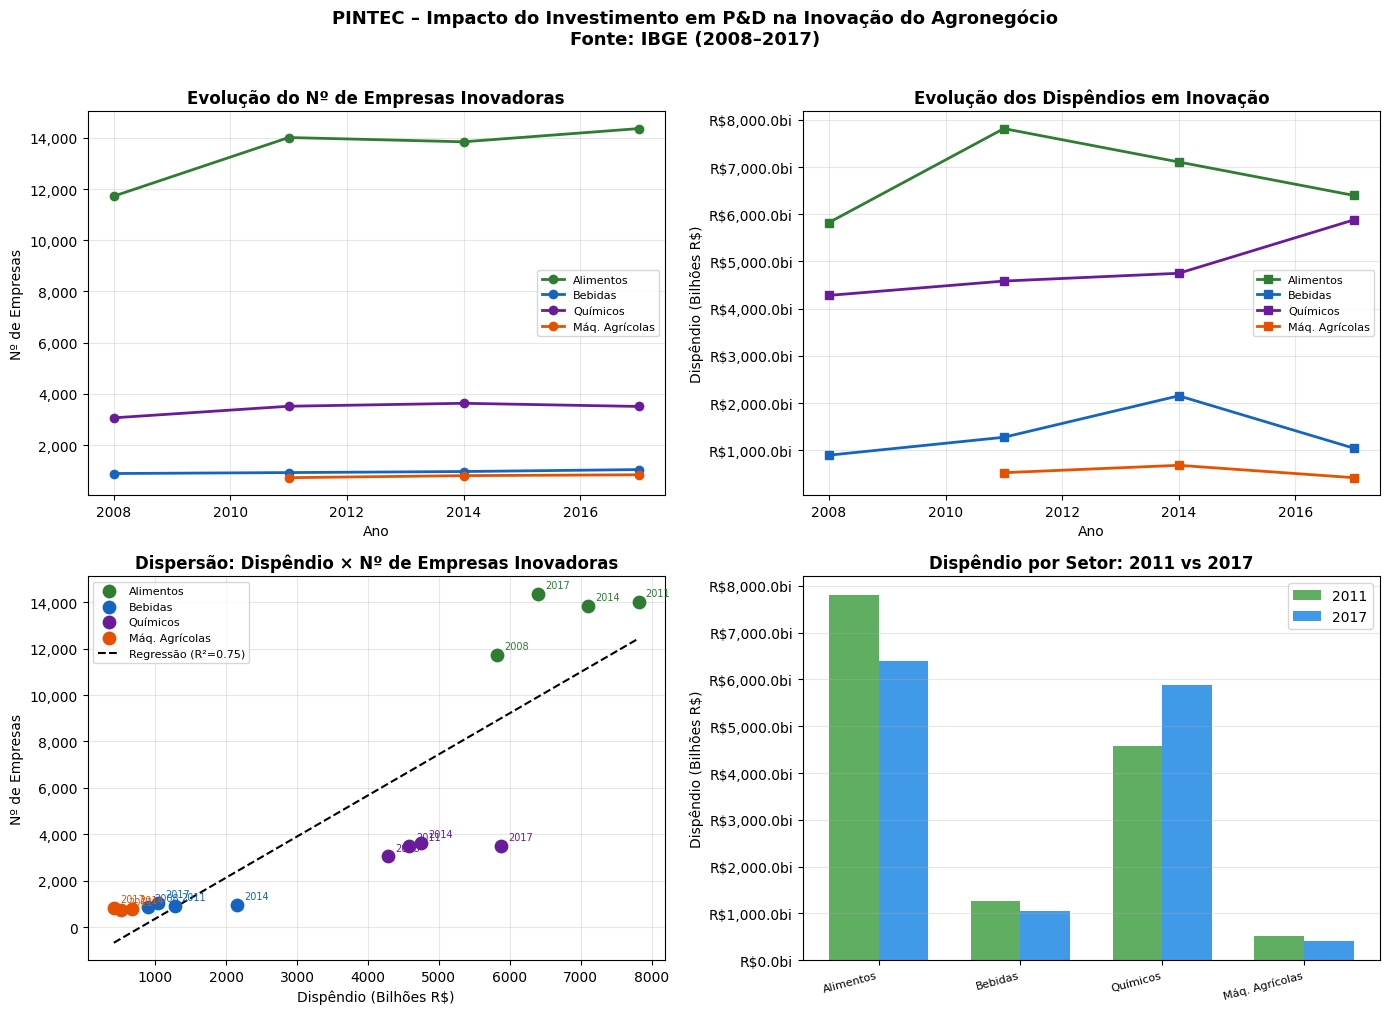

In [2]:
"""
=======================================================================
ANÁLISE PINTEC - Impacto do Investimento em P&D na Adoção de Inovações
no Agronegócio
Dados: IBGE - Pesquisa de Inovação (PINTEC) | Anos: 2008, 2011, 2014, 2017
=======================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

# ── Paleta de cores consistente para os gráficos ──────────────────────
CORES = ["#2E7D32", "#1565C0", "#6A1B9A", "#E65100"]
ANOS  = [2008, 2011, 2014, 2017]

# =======================================================================
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# =======================================================================

def carregar_tabela(caminho, nome_coluna_valor):
    """
    Lê um CSV do PINTEC (separador ';', BOM UTF-8) e retorna um
    DataFrame limpo com colunas: ['setor', 2008, 2011, 2014, 2017].
    """
    with open(caminho, encoding="utf-8-sig") as f:
        linhas = f.readlines()

    # As 5 primeiras linhas são cabeçalho; os dados começam na linha 5
    # e terminam antes de "Fonte:"
    dados_brutos = []
    for linha in linhas[5:]:
        linha = linha.strip()
        if not linha or linha.startswith('"Fonte'):
            break
        # Remove aspas e divide pelo separador ';'
        partes = [p.strip('"') for p in linha.split(";")]
        if len(partes) >= 5:
            dados_brutos.append(partes[:5])

    df = pd.DataFrame(dados_brutos, columns=["setor", "2008", "2011", "2014", "2017"])

    # Converte valores: "..." e "-" viram NaN; remove pontos de milhar
    for ano in ["2008", "2011", "2014", "2017"]:
        df[ano] = (
            df[ano]
            .replace({"...": np.nan, "-": np.nan, "..": np.nan, "X": np.nan})
            .str.replace(".", "", regex=False)   # remove separador de milhar
            .str.replace(",", ".", regex=False)  # troca vírgula decimal por ponto
            .astype(float)
        )
        df = df.rename(columns={ano: int(ano)})

    # Apelidos curtos para os setores (facilita os gráficos)
    apelidos = {
        "10 FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS":
            "Alimentos",
        "11 FABRICAÇÃO DE BEBIDAS":
            "Bebidas",
        "20 FABRICAÇÃO DE PRODUTOS QUÍMICOS":
            "Químicos",
        "28.3 Fabricação de tratores e de máquinas e equipamentos para a agricultura e pecuária":
            "Máq. Agrícolas",
    }
    df["setor"] = df["setor"].map(apelidos).fillna(df["setor"])
    return df


df_empresas   = carregar_tabela("tabela5453.csv", "n_empresas")
df_dispendios = carregar_tabela("tabela5464.csv", "dispendio_mil_reais")

print("✔  Dados carregados com sucesso.")
print("\n── Nº de empresas com inovação ──")
print(df_empresas.to_string(index=False))
print("\n── Dispêndios em inovação (Mil R$) ──")
print(df_dispendios.to_string(index=False))


# =======================================================================
# 2. MONTAGEM DO DATAFRAME ANALÍTICO (formato longo)
# =======================================================================
# Transformamos os dois DataFrames de "wide" para "long" e os unimos,
# criando uma linha por (setor, ano).

def wide_para_long(df, nome_variavel):
    return df.melt(
        id_vars="setor",
        value_vars=ANOS,
        var_name="ano",
        value_name=nome_variavel
    )

long_emp = wide_para_long(df_empresas,   "n_empresas")
long_dis = wide_para_long(df_dispendios, "dispendio_mil_reais")

painel = pd.merge(long_emp, long_dis, on=["setor", "ano"])
painel["ano"] = painel["ano"].astype(int)
painel = painel.dropna()   # remove linhas com NaN (ex.: 2008 de Máq. Agrícolas)

print(f"\n── Painel analítico ({len(painel)} observações) ──")
print(painel.to_string(index=False))


# =======================================================================
# 3. ESTATÍSTICA DESCRITIVA
# =======================================================================
print("\n" + "="*60)
print("3. ESTATÍSTICA DESCRITIVA")
print("="*60)

desc_emp = painel.groupby("setor")["n_empresas"].describe().round(1)
desc_dis = painel.groupby("setor")["dispendio_mil_reais"].describe().round(1)

print("\nNº de empresas inovadoras por setor:")
print(desc_emp[["mean", "std", "min", "max"]].rename(
    columns={"mean": "Média", "std": "Desvio-P.", "min": "Mínimo", "max": "Máximo"}
))

print("\nDispêndios (Mil R$) por setor:")
print(desc_dis[["mean", "std", "min", "max"]].rename(
    columns={"mean": "Média", "std": "Desvio-P.", "min": "Mínimo", "max": "Máximo"}
))


# =======================================================================
# 4. CORRELAÇÃO DE PEARSON
# =======================================================================
print("\n" + "="*60)
print("4. CORRELAÇÃO DE PEARSON  (dispêndio ↔ nº empresas inovadoras)")
print("="*60)

r, p = stats.pearsonr(painel["dispendio_mil_reais"], painel["n_empresas"])
print(f"\n  Coeficiente r = {r:.4f}")
print(f"  Valor-p       = {p:.4f}")
if p < 0.05:
    print("  → Correlação SIGNIFICATIVA ao nível de 5%.")
else:
    print("  → Correlação não significativa ao nível de 5%.")

# Correlação por setor
print("\nCorrelação por setor:")
for setor, grupo in painel.groupby("setor"):
    if len(grupo) >= 3:
        r_s, p_s = stats.pearsonr(grupo["dispendio_mil_reais"], grupo["n_empresas"])
        sig = "✔ sig." if p_s < 0.05 else "—"
        print(f"  {setor:<18}  r = {r_s:+.4f}  p = {p_s:.4f}  {sig}")


# =======================================================================
# 5. REGRESSÃO LINEAR SIMPLES
# =======================================================================
print("\n" + "="*60)
print("5. REGRESSÃO LINEAR SIMPLES")
print("   Variável dependente   : Nº de empresas inovadoras")
print("   Variável independente : Dispêndio em inovação (Mil R$)")
print("="*60)

X = painel[["dispendio_mil_reais"]].values
y = painel["n_empresas"].values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)

r2   = r2_score(y, y_pred)
incl = modelo.coef_[0]
orig = modelo.intercept_

# Estatística t e p-valor para o coeficiente via scipy
slope, intercept, r_val, p_val, stderr = stats.linregress(
    painel["dispendio_mil_reais"], painel["n_empresas"]
)

print(f"\n  Equação : Nº_empresas = {orig:.2f} + {incl:.6f} × Dispêndio")
print(f"  R²       = {r2:.4f}  ({r2*100:.1f}% da variância explicada)")
print(f"  Coef. β₁ = {incl:.6f}  (p = {p_val:.4f})")
print(f"  Intercepto β₀ = {orig:.2f}")

if p_val < 0.05:
    print("  → Coeficiente SIGNIFICATIVO: o investimento prevê inovação.")
else:
    print("  → Coeficiente não significativo ao nível de 5%.")

# Interpretação aplicada
print(f"\n  Interpretação prática:")
print(f"  A cada R$ 1 bilhão investido em inovação, estima-se um acréscimo")
print(f"  de {incl * 1_000_000:.0f} empresas adotando inovações no setor.")


# =======================================================================
# 6. VISUALIZAÇÕES
# =======================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "PINTEC – Impacto do Investimento em P&D na Inovação do Agronegócio\n"
    "Fonte: IBGE (2008–2017)",
    fontsize=13, fontweight="bold", y=1.01
)

setores = painel["setor"].unique()

# ── Gráfico 1: Evolução do Nº de empresas inovadoras ──────────────────
ax1 = axes[0, 0]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor].sort_values("ano")
    ax1.plot(sub["ano"], sub["n_empresas"], marker="o", label=setor,
             color=CORES[i], linewidth=2)
ax1.set_title("Evolução do Nº de Empresas Inovadoras", fontweight="bold")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Nº de Empresas")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── Gráfico 2: Evolução dos Dispêndios (Mil R$) ───────────────────────
ax2 = axes[0, 1]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor].sort_values("ano")
    ax2.plot(sub["ano"], sub["dispendio_mil_reais"] / 1_000,
             marker="s", label=setor, color=CORES[i], linewidth=2)
ax2.set_title("Evolução dos Dispêndios em Inovação", fontweight="bold")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Dispêndio (Bilhões R$)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.1f}bi"))
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── Gráfico 3: Dispersão com linha de regressão ───────────────────────
ax3 = axes[1, 0]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor]
    ax3.scatter(
        sub["dispendio_mil_reais"] / 1_000,
        sub["n_empresas"],
        label=setor, color=CORES[i], s=80, zorder=3
    )
    # Anota o ano em cada ponto
    for _, row in sub.iterrows():
        ax3.annotate(str(row["ano"]),
                     (row["dispendio_mil_reais"] / 1_000, row["n_empresas"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7,
                     color=CORES[i])

# Linha de regressão
x_range = np.linspace(painel["dispendio_mil_reais"].min(),
                      painel["dispendio_mil_reais"].max(), 100)
y_range = modelo.predict(x_range.reshape(-1, 1))
ax3.plot(x_range / 1_000, y_range, "--", color="black", linewidth=1.5,
         label=f"Regressão (R²={r2:.2f})")
ax3.set_title("Dispersão: Dispêndio × Nº de Empresas Inovadoras", fontweight="bold")
ax3.set_xlabel("Dispêndio (Bilhões R$)")
ax3.set_ylabel("Nº de Empresas")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── Gráfico 4: Barras comparativas por setor (2008 vs 2017) ───────────
ax4 = axes[1, 1]
setores_lista = list(setores)
n = len(setores_lista)
x  = np.arange(n)
w  = 0.35

# Apenas anos com dados completos para todos os setores
anos_disp = {
    "2011": painel[painel["ano"] == 2011],
    "2017": painel[painel["ano"] == 2017],
}
for idx, (rotulo, sub) in enumerate(anos_disp.items()):
    valores = [sub[sub["setor"] == s]["dispendio_mil_reais"].values[0] / 1_000
               if s in sub["setor"].values else 0
               for s in setores_lista]
    ax4.bar(x + idx * w, valores, w, label=rotulo,
            color=["#43A047", "#1E88E5"][idx], alpha=0.85)

ax4.set_title("Dispêndio por Setor: 2011 vs 2017", fontweight="bold")
ax4.set_xticks(x + w / 2)
ax4.set_xticklabels([s[:14] for s in setores_lista], rotation=15, ha="right", fontsize=8)
ax4.set_ylabel("Dispêndio (Bilhões R$)")
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.1f}bi"))
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("graficos_pintec.png", dpi=180, bbox_inches="tight")
print("\n✔  Gráficos salvos em 'graficos_pintec.png'.")


# =======================================================================
# 7. SUMÁRIO PARA O ARTIGO
# =======================================================================
print("\n" + "="*60)
print("7. SUMÁRIO PARA O ARTIGO CIENTÍFICO (SIMPEP)")
print("="*60)
print(f"""
Título sugerido:
  Investimento em P&D e Adoção de Inovações no Agronegócio:
  Uma Análise a partir da PINTEC (2008–2017)

Principais achados:
  • Setor de maior dispêndio médio:
    {desc_dis['mean'].idxmax()} ({desc_dis['mean'].max():,.0f} Mil R$)

  • Setor com maior nº médio de empresas inovadoras:
    {desc_emp['mean'].idxmax()} ({desc_emp['mean'].max():,.0f} empresas)

  • Correlação geral (Pearson):
    r = {r:.4f} | p = {p:.4f} → {"Significativa" if p < 0.05 else "Não-significativa"} (α=5%)

  • Regressão Linear:
    R² = {r2:.4f} | Coef. = {incl:.4e}
    A cada R$ 1 bi investido → {incl * 1_000_000:.0f} empresas adicionais inovando

  • Crescimento do dispêndio (2011→2017) em Máquinas Agrícolas:
    {((painel[(painel.setor=="Máq. Agrícolas")&(painel.ano==2017)]["dispendio_mil_reais"].values[0] /
       painel[(painel.setor=="Máq. Agrícolas")&(painel.ano==2011)]["dispendio_mil_reais"].values[0]) - 1)*100:.1f}%
""")

print("Análise concluída! ✔")
